### Resource Comparison

### Qubits Or Qumode comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
## baselines: Qubit(QAOA, ChocoQ, Bosonic QAOA, Ours)
if not os.path.exists('results'):
    os.makedirs('results')
with open('results/QuWidth.csv', 'w') as f:
    f.write('cutoff,method,qubit_width,qumode_width,word\n')
    for cutoff in np.arange(5,100,5):
        binary_encoding = round(np.log2(cutoff),0)
        for method in ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']:
            if method == 'Qubit-binary':
                qubit_width = binary_encoding
                qumode_width = 0
            elif method == 'Qubit-onehot':
                qubit_width = cutoff
                qumode_width = 0
            elif method == 'bosonicQAOA':
                qubit_width = 0
                qumode_width = 1
            elif method == 'HybridCVDV':
                qubit_width = 1
                qumode_width = 1
            f.write(f"{cutoff},{method},{qubit_width},{qumode_width},{(int(np.log2(cutoff))+1)/(qubit_width+qumode_width)}\n")

width_data = pd.read_csv('results/QuWidth.csv')

In [3]:
width_data

,cutoff,method,qubit_width,qumode_width,word
0,5,Qubit-binary,2.0,0,1.500000
1,5,Qubit-onehot,5.0,0,0.600000
2,5,bosonicQAOA,0.0,1,3.000000
3,5,HybridCVDV,1.0,1,1.500000
4,10,Qubit-binary,3.0,0,1.333333
...,...,...,...,...,...
71,90,HybridCVDV,1.0,1,3.500000
72,95,Qubit-binary,7.0,0,1.000000
73,95,Qubit-onehot,95.0,0,0.073684
74,95,bosonicQAOA,0.0,1,7.000000


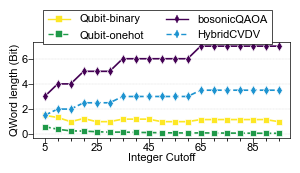

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator  
from matplotlib.lines import Line2D
## bar plot legend
import matplotlib.patches as mpatches
width_pt = 240
inches_per_pt = 1 / 72.27
fig_width = width_pt * inches_per_pt

# 计算子图尺寸（16:9比例）
subplot_width = fig_width / 2  # 4列
subplot_height = subplot_width * 3 /4
fig_height = subplot_height  # 3行
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "figure.figsize": (fig_width, fig_height),
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    ## tick label padding
    "xtick.major.pad": 0.3,
    "ytick.major.pad": 0.3,
    "legend.fontsize": 8,
    "axes.titlesize": 8,
    "lines.markersize": 5,
    "lines.linewidth": 1.2,
    "lines.markeredgewidth": 0.3,
    "grid.linewidth": 0.2,
    "grid.alpha": 0.5,
    "grid.color": "gray",
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
})
orderindex = {}
latencys = {}
thresholdsvals = {}
baselines = ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']
# Plot threshold vs decoder setting pair
fig, axs = plt.subplots(1, 1, figsize=(fig_width, fig_height))

## set x and y axis limits
labels = ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']
colors = {'Qubit-binary': '#FDE725', 'Qubit-onehot': '#1F9948', 'bosonicQAOA': '#440154','HybridCVDV': '#1D93D0'}
linestyle = {'Qubit-binary': '-', 'Qubit-onehot': '--', 'bosonicQAOA': '-','HybridCVDV': '--'}
markers = {'Qubit-binary': 's', 'Qubit-onehot': 's', 'bosonicQAOA': 'd','HybridCVDV': 'd'}

ax = axs
ax.grid(True,axis='y', linestyle='--')

for method in baselines:
    data = width_data[width_data['method'] == method]
    ax.plot(data['cutoff'], data['word'], marker=markers[method], color=colors[method], 
    markeredgecolor='white', markeredgewidth=0.5, linestyle=linestyle[method], label=method)

ax.set_xticks(data['cutoff'],minor=True)
ax.set_xticks(np.arange(5,100,20),minor=False)
# ax.set_xticklabels(distances)
## draw horizontal line at y=100
ax.set_xlabel(r'Integer Cutoff', labelpad=0)
ax.set_ylabel('QWord length (Bit)',labelpad=1)

ax.grid(True,axis='y')
# ax.text(-0.18, -0.35, "(b)", transform=ax.transAxes, fontsize=8,
#                 verticalalignment='bottom', horizontalalignment='right')

legend_handles = [
    Line2D([0], [0], marker=markers[label], color=colors[label], lw=1, linestyle=linestyle[label], markerfacecolor=colors[label]
,markersize=4, label=label) for label in labels
]





# 添加全局图例（顶部居中）
legend = fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18), # 调整 y 位置
    framealpha=1,
    ncol=2,                      # 横向排列
    frameon=True,               # 去掉边框
    edgecolor = 'black',        # 边框颜色
    fancybox=False,             # 去掉圆角
    shadow=False,               # 去掉阴影
)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(0.5)
# # set facecolor to gray
# fig.patch.set_facecolor('#F2F2F2')
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/quword.svg', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


#### Qubit width

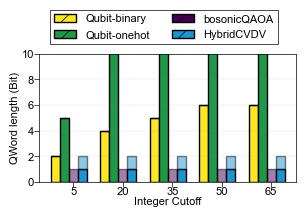

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator  
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
## bar plot legend
import matplotlib.patches as mpatches
width_pt = 240
inches_per_pt = 1 / 72.27
fig_width = width_pt * inches_per_pt

# 计算子图尺寸（16:9比例）
subplot_width = fig_width / 2  # 4列
subplot_height = subplot_width 
fig_height = subplot_height  # 3行
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "figure.figsize": (fig_width, fig_height),
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    ## tick label padding
    "xtick.major.pad": 0.3,
    "ytick.major.pad": 0.3,
    "legend.fontsize": 8,
    "axes.titlesize": 8,
    "lines.markersize": 2.5,
    "lines.linewidth": 0.7,
    "lines.markeredgewidth": 0,
    "grid.linewidth": 0.2,
    "grid.alpha": 0.5,
    "grid.color": "gray",
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "hatch.color": "black",
    "hatch.linewidth": 0.5,
})
orderindex = {}
latencys = {}
thresholdsvals = {}
baselines = ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']
# Plot threshold vs decoder setting pair
fig, axs = plt.subplots(1, 1, figsize=(fig_width, fig_height))

## set x and y axis limits
labels = ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']
colors = {'Qubit-binary': '#FDE725', 'Qubit-onehot': '#1F9948', 'bosonicQAOA': '#440154','HybridCVDV': '#1D93D0'}
white_colors = {'Qubit-binary': '#FDE725', 'Qubit-onehot': '#1F9948', 'bosonicQAOA': '#440154','HybridCVDV': '#1D93D0'}
linestyle = {'Qubit-binary': '-', 'Qubit-onehot': '--', 'bosonicQAOA': '-','HybridCVDV': '--'}
markers = {'Qubit-binary': 's', 'Qubit-onehot': 's', 'bosonicQAOA': 'd','HybridCVDV': 'd'}

ax = axs
ax.grid(True,axis='y', linestyle='--')
idxgroup = 0
group_ticks = []
cutoffs = [5,20,35,50,65]
for cutoff in cutoffs:
    idxoff = 0
    for method in width_data['method'].unique():
        data = width_data[(width_data['cutoff'] == cutoff) & (width_data['method'] == method)]
        ax.bar(idxgroup + idxoff*2, data['qubit_width'], width = 2, color=colors[method], edgecolor='black', label=method)
        ax.bar(idxgroup + idxoff*2, data['qumode_width'], bottom = data['qubit_width'], width = 2,  color=colors[method], alpha=0.5, edgecolor='black', label=method)
        idxoff += 1
    group_ticks.append(idxgroup+4)
    idxgroup += 11

ax.set_xticks(group_ticks)
ax.set_xticklabels(cutoffs)
# ax.set_xticks([5,10,15,20,25],minor=True)
# ax.set_xticks(np.arange(5,100,20),minor=False)
# ax.set_xticklabels(distances)
## draw horizontal line at y=100
ax.set_xlabel(r'Integer Cutoff', labelpad=0)
ax.set_ylabel('QWord length (Bit)',labelpad=1)

ax.grid(True,axis='y')
ax.set_ylim(0,10)
# ax.set_yscale('log')

legend_handles = [
    Patch(
        facecolor=colors[label],
        edgecolor='black',
        hatch='//',
        label=label
    )
    for label in labels
]


# 添加全局图例（顶部居中）
legend = fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18), # 调整 y 位置
    framealpha=1,
    ncol=2,                      # 横向排列
    frameon=True,               # 去掉边框
    edgecolor = 'black',        # 边框颜色
    fancybox=False,             # 去掉圆角
    shadow=False,               # 去掉阴影
)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(0.5)
# # set facecolor to gray
# fig.patch.set_facecolor('#F2F2F2')

plt.savefig('figs/quwidth.svg', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


## Circuit depth

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator  
from matplotlib.lines import Line2D
## bar plot legend
import matplotlib.patches as mpatches

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
## baselines: Qubit(QAOA, ChocoQ, Bosonic QAOA, Ours)
if not os.path.exists('results'):
    os.makedirs('results')
with open('results/CircuitDepth.csv', 'w') as f:
    f.write('numvariable,num_constraints,problem_id,method,numlayer,circuit_depth,latency\n')
    for numvariable in np.arange(3,10,1):
        for num_constraints in np.arange(int(numvariable*0.5),int(numvariable*0.8),1):
            for num_layer in np.arange(1,10,1):
                for problem_id in range(10):
                    for method in ['Qubit-binary', 'Qubit-onehot', 'bosonicQAOA','HybridCVDV']:
                        f.write(f"{numvariable},{num_constraints},{problem_id},{method},{num_layer},{np.random.randint(1,100)},{np.random.randint(1,100)}\n")

depth_data = pd.read_csv('results/CircuitDepth.csv')

In [8]:
depth_data


,numvariable,num_constraints,problem_id,method,numlayer,circuit_depth,latency
0,3,1,0,Qubit-binary,1,80,35
1,3,1,0,Qubit-onehot,1,32,37
2,3,1,0,bosonicQAOA,1,15,58
3,3,1,0,HybridCVDV,1,59,1
4,3,1,1,Qubit-binary,1,91,12
...,...,...,...,...,...,...,...
4315,9,6,8,HybridCVDV,9,70,57
4316,9,6,9,Qubit-binary,9,2,53
4317,9,6,9,Qubit-onehot,9,77,92
4318,9,6,9,bosonicQAOA,9,32,74
